### Chain Using LangGraph
In this section we will see how we can build a simple chain using Langgraph that uses 4 important concepts

- How to use chat messages as our graph state
- How to use chat models in graph nodes
- How to bind tools to our LLM in chat models
- How to execute the tools call in our graph nodes 

In [2]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


#### How to use chat messages as our graph state
##### Messages

We can use messages which can be used to capture different roles within a conversation.
LangChain has various message types including HumanMessage, AIMessage, SystemMessage and ToolMessage.
These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Every message have these important components.

- content - content of the message
- name - Specify the name of author
- response_metadata - optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)



In [3]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint ## printing in a better format

messages=[AIMessage(content=f"Please tell me how can I help",name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding",name="VK"))
messages.append(AIMessage(content=f"Which programming language you want to learn",name="LLMModel"))
messages.append(HumanMessage(content=f"I want to learn python programming language",name="VK"))

for message in messages:
    message.pretty_print()



================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Krish

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language you want to learn
================================ Human Message =================================
Name: Krish

I want to learn python programming language


### Chat Models

We can use the sequence of message as input with the chatmodels using LLM's and OPENAI.

In [4]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="Llama-3.1-8b-instant")
result=llm.invoke(messages)

e:\GitHub\Python\Python_Agentic_AI_With_Langchain_and_Langraph\practice_agentic_ai\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
result.response_metadata

{'token_usage': {'completion_tokens': 534,
  'prompt_tokens': 76,
  'total_tokens': 610,
  'completion_time': 0.988451188,
  'completion_tokens_details': None,
  'prompt_time': 0.007632575,
  'prompt_tokens_details': None,
  'queue_time': 0.045241974,
  'total_time': 0.996083763},
 'model_name': 'Llama-3.1-8b-instant',
 'system_fingerprint': 'fp_4387d3edbb',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

## Router

When LLM decides to tool call or direct response, the macanism is called router.
- routers will have some binding with one or more tools.

### Tools
Tools can be integrated with the LLM models to interact with external systems. External systems can be API's, third party tools.

Whenever a query is asked the model can choose to call the tool and this query is based on the 
natural language input and this will return an output that matches the tool's schema

In [6]:
def add(a:int,b:int)->int:
    '''This function adds two numbers and returns the result'''
    return a+b

In [7]:
llm_with_tools=llm.bind_tools([add])
llm_call = llm_with_tools.invoke([HumanMessage(content=f"Please add 2 and 3",name="Vk")])

In [9]:
llm_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 3},
  'id': 'qra2s0k2x',
  'type': 'tool_call'}]

### Messages as state

In [10]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    message:list[AnyMessage]


## Reducers
Now, we have a minor problem!

As we discussed, each node will return a new value for our state key messages.
But, this new value will override the prior messages value.

As our graph runs, we want to append messages to our messages state key.
We can use reducer functions to address this.

Reducers allow us to specify how state updates are performed.
If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before.

But, to append messages, we can use the pre-built add_messages reducer.
This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our messages key with the add_messages reducer function as metadata.

In [11]:
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    message: Annotated[list[AnyMessage], add_messages]
    name: str

### Reducers with add_messages

In [12]:
initial_messages = [AIMessage(content=f"Please tell me how can I help",name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding",name="VK"))
initial_messages

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='VK')]

In [13]:
ai_message = AIMessage(content=f"Which programming language you want to learn",name="LLMModel")
ai_message

AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

In [15]:
## add_messages is reducer function that appends new message instead of replacing
add_messages(initial_messages, ai_message)

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='dea89b3f-3cae-4178-9761-a0b03914c821', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='VK', id='2f27eaf0-3ee8-4188-a5e1-c6e95e1932f1'),
 AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='eaed3dd4-43fb-4582-8334-3025801d5d38', tool_calls=[], invalid_tool_calls=[])]

In [41]:
## chat bot node functionality
def llm_tool(state:State)->State:
    return {"message": [llm_with_tools.invoke(state["message"]) ]}

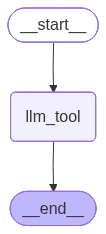

In [42]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("llm_tool",llm_tool)

builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool",END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [43]:
## invocation of graph
## here tool methods there but there is no tool node

messages = graph.invoke({"message": [HumanMessage(content=f"Please add 2 and 3",name="Vk")]})

for message in messages["message"]:
    message.pretty_print()

================================ Human Message =================================
Name: Vk

Please add 2 and 3
================================== Ai Message ==================================
Tool Calls:
  add (tsbqmdmbj)
 Call ID: tsbqmdmbj
  Args:
    a: 2
    b: 3


In [44]:
tools = [add]

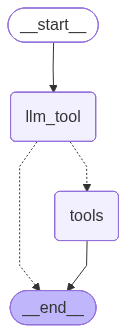

In [ ]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

builder = StateGraph(State)

## Add nodes
builder.add_node("llm_tool",llm_tool)
## Add tool node
builder.add_node("tools",ToolNode(tools, messages_key="message"))

## Add edges
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # If the latest message/result from llm assistant is a tool call --->>> tools_condition routes/results to tools
    # If the latest message/result from llm assistant is not a tool call --->>> tools_condition routes/results to END
    lambda state: tools_condition(state, messages_key="message"),
    {"tools": "tools", "__end__": END}
)
builder.add_edge("tools",END)


## Generate and display graph
graph_builder = builder.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [54]:
## invocation of graph
## here tool methods is there but there is also tool node

messages = graph_builder.invoke({"message": [HumanMessage(content="Please add 2 and 3", name="Vk")]})

for message in messages["message"]:
    message.pretty_print()

================================ Human Message =================================
Name: Vk

Please add 2 and 3
================================== Ai Message ==================================
Tool Calls:
  add (a5nv2c56d)
 Call ID: a5nv2c56d
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: add

5


In [55]:
## invocation of graph
## here tool methods is there but there is also tool node

messages = graph_builder.invoke({"message": [HumanMessage(content="what is machine learning?", name="Vk")]})

for message in messages["message"]:
    message.pretty_print()

================================ Human Message =================================
Name: Vk

what is machine learning?
================================== Ai Message ==================================

brave_search{"query": "machine learning definition"}
